In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
import pandas as pd
import matplotlib.ticker as ticker
import re

In [2]:
workspace_base_path = lambda item: os.path.join('/checkpoint/maui/zhaobc/scientist/workspace', item)


In [3]:
ori_results = find_levels_in_configs_glob(
    [
        '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250412_*',
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
        '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250412_*',
         '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250408_*',
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
        '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250409_*',
    ]
)

Found 173 directories


In [4]:
ori_results

{'record_13_20250412_122737_1968005-1968001-2': {'record': 13,
  'levels': [12],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'aide',
  'model': 'o3-mini',
  'n_initial_hypotheses': 3,
  'n_hypotheses': 1},
 'record_7_20250412_085737_1966835-1966817-6': {'record': 7,
  'levels': [1],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'aide',
  'model': 'o3-mini',
  'n_initial_hypotheses': 3,
  'n_hypotheses': 1},
 'record_2_20250412_085737_1966830-1966817-1': {'record': 2,
  'levels': [1],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'aide',
  'model': 'o3-mini',
  'n_initial_hypotheses': 3,
  'n_hypotheses': 1},
 'record_9_20250412_085642_1966828-1966816-8': {'record': 9,
  'levels': [1],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'aide',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': 3,
  'n_hypotheses': 1},
 'record_14_20250412_085921_1966843-1966818-3': {'record': 14,
  'levels': [1],
  'ideator': 'dummy',
  'know

In [5]:
folder_info = ori_results

r1_aide_dummy_no_knowledge_l1 = []
o3_aide_dummy_no_knowledge_l1 = []
r1_aide_dummy_no_knowledge_l12 = []
o3_aide_dummy_no_knowledge_l12 = []

print("--" * 10)
for folder_name, info in folder_info.items():
    if info['model'] == 'o3-mini':
        if info['runner'] == 'aide':
            if info['ideator'] == 'dummy':
                if info['levels'][0] == 1:
                    if info['n_initial_hypotheses'] == 1:
                        # print(f"{folder_name}: o3, aide, dummy, coder nok")
                        o3_aide_dummy_no_knowledge_l1.append(folder_name)

print("--" * 10)
for folder_name, info in folder_info.items():
    if info['model'] == 'deepseek-r1':
        if info['runner'] == 'aide':
            if info['ideator'] == 'dummy':
                if info['levels'][0] == 1:
                    if info['n_initial_hypotheses'] == 1:
                        # print(f"{folder_name}: r1, aide, dummy, coder nok")
                        r1_aide_dummy_no_knowledge_l1.append(folder_name)
print("--" * 10)
for folder_name, info in folder_info.items():
    if info['model'] == 'o3-mini':
        if info['runner'] == 'aide':
            if info['ideator'] == 'dummy':
                if info['levels'][0] == 12:
                    # print(f"{folder_name}: o3, aide, dummy, coder nok")
                    o3_aide_dummy_no_knowledge_l12.append(folder_name)

print("--" * 10)
for folder_name, info in folder_info.items():
    if info['model'] == 'deepseek-r1':
        if info['runner'] == 'aide':
            if info['ideator'] == 'dummy':
                if info['levels'][0] == 12:
                    # print(f"{folder_name}: r1, aide, dummy, coder nok")
                    r1_aide_dummy_no_knowledge_l12.append(folder_name)

--------------------
--------------------
--------------------
--------------------


In [6]:
r1_aide_dummy_no_knowledge_l1 = {k: folder_info[k] for k in r1_aide_dummy_no_knowledge_l1}
o3_aide_dummy_no_knowledge_l1 = {k: folder_info[k] for k in o3_aide_dummy_no_knowledge_l1}
r1_aide_dummy_no_knowledge_l12 = {k: folder_info[k] for k in r1_aide_dummy_no_knowledge_l12}
o3_aide_dummy_no_knowledge_l12 = {k: folder_info[k] for k in o3_aide_dummy_no_knowledge_l12}


In [7]:
r1_aide_dummy_no_knowledge_l12

{'record_14_20250412_122703_1967986-1967979-3': {'record': 14,
  'levels': [12],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'aide',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': 3,
  'n_hypotheses': 1},
 'record_5_20250412_122635_1967972-1967967-4': {'record': 5,
  'levels': [12],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'aide',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': 3,
  'n_hypotheses': 1},
 'record_13_20250412_122703_1967985-1967979-2': {'record': 13,
  'levels': [12],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'aide',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': 3,
  'n_hypotheses': 1},
 'record_10_20250412_122635_1967967-1967967-9': {'record': 10,
  'levels': [12],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'aide',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': 3,
  'n_hypotheses': 1},
 'record_1_20250412_122635_1967968-1967967-0': {'record': 1,
  'levels': [12],
  'ideator'

In [8]:

# o3_bon_dummy_no_knowledge_l1['record_3_20250408_155217_1747665-1747662-2']['metrics']
# for index, row in o3_bon_dummy_no_knowledge_l1['record_3_20250408_155217_1747665-1747662-2']['metrics'].iterrows():
#     print(f"Index: {index}, Row: {row.to_dict()}")

In [9]:
def process_metrics(record):
    for k, v in record.items():
        metrics = gather_metrics(
            workspace_base_path(k),
            metrics=['val_loss', 'train_time'],
            workspace_template_path=os.path.join(
                'workspace_templates', 
                'nanogpt_speedrun', 
                f"record_{v['record']}"
            )
        )
        metrics.loc[metrics['val_loss'] >= 3.29, 'train_time'] = np.nan
        record[k]['metrics'] = metrics
    return record


In [10]:
r1_aide_dummy_no_knowledge_l1 = process_metrics(r1_aide_dummy_no_knowledge_l1)
o3_aide_dummy_no_knowledge_l1 = process_metrics(o3_aide_dummy_no_knowledge_l1)
r1_aide_dummy_no_knowledge_l12 = process_metrics(r1_aide_dummy_no_knowledge_l12)
o3_aide_dummy_no_knowledge_l12 = process_metrics(o3_aide_dummy_no_knowledge_l12)


In [11]:
for k, v in r1_aide_dummy_no_knowledge_l12.items():
    metrics = v['metrics']
    print(f"Record: {k}, min train time idx: {metrics['train_time'].idxmin()}")

Record: record_14_20250412_122703_1967986-1967979-3, min train time idx: 0
Record: record_5_20250412_122635_1967972-1967967-4, min train time idx: 16
Record: record_13_20250412_122703_1967985-1967979-2, min train time idx: 0
Record: record_10_20250412_122635_1967967-1967967-9, min train time idx: 0
Record: record_1_20250412_122635_1967968-1967967-0, min train time idx: 19
Record: record_7_20250412_122635_1967974-1967967-6, min train time idx: 7
Record: record_16_20250412_122703_1967988-1967979-5, min train time idx: 16
Record: record_11_20250412_122703_1967983-1967979-0, min train time idx: 17
Record: record_9_20250412_122635_1967976-1967967-8, min train time idx: 10
Record: record_3_20250412_122635_1967970-1967967-2, min train time idx: 0
Record: record_15_20250412_122703_1967987-1967979-4, min train time idx: 18
Record: record_6_20250412_122635_1967973-1967967-5, min train time idx: 0
Record: record_17_20250412_122703_1967989-1967979-6, min train time idx: 20
Record: record_4_2025041

In [12]:
def convert_to_dict(record):
    results = {}
    for k, v in record.items():
        # record_num = int(k.split('-')[-1])
        ## the +1 here is because the process is 0-indexed but record number is 1-indexed
        # results[record_num + 1] = v['metrics']['train_time'].min()
        # record_num = k.split('_2025')[0].split('_')[-1]
        pattern = r"^record_(\d+)_"
        match = re.match(pattern, k)
        record_num = int(match.group(1))
        results[record_num] = v['metrics']['train_time'].min()
    return results

# r1_bon_results = convert_to_dict(r1_bon_dummy_no_knowledge_l1)
r1_aide_results = convert_to_dict(r1_aide_dummy_no_knowledge_l1)
r1_aide_l12_results = convert_to_dict(r1_aide_dummy_no_knowledge_l12)
# o3_bon_results = convert_to_dict(o3_bon_dummy_no_knowledge_l1)
o3_aide_results = convert_to_dict(o3_aide_dummy_no_knowledge_l1)
o3_aide_l12_results = convert_to_dict(o3_aide_dummy_no_knowledge_l12)

In [13]:

human_train_time_dict = {
    1: 2936369,
    2: 2304681,
    3: 1282839,
    4: 1301740,
    5: 949528,
    6: 766259,
    7: 773072,
    8: 662205,
    9: 505531,
    10: 477150,
    11: 442985,
    12: 317839,
    13: 289805,
    14: 273107,
    15: 241463,
    16: 232971,
    17: 220374,
    18: 211840,
    19: 199442
}

In [14]:
def compute_gap_in_percentage(
        model_time, 
        human_time=human_train_time_dict, 
    ):
    gaps = {}
    for k, v in human_time.items():
        if (k + 1) not in human_time:
            continue
        gaps[k] = v - human_time[k+1]
    
    recovered_times = {}
    for k, v in model_time.items():
        recovered_time = human_time[k] - v
        recovered_times[k] = recovered_time

    recovered_gap_in_percentage = {}
    for k, v in recovered_times.items():
        if (k + 1) not in gaps:
            continue
        recovered_gap_in_percentage[k] = v / gaps[k] if gaps[k] > 0 else 0

    return recovered_gap_in_percentage



In [15]:
# r1_bon_gap_in_percentage = compute_gap_in_percentage(r1_bon_results)
r1_aide_gap_in_percentage = compute_gap_in_percentage(r1_aide_results)
r1_aide_l12_gap_in_percentage = compute_gap_in_percentage(r1_aide_l12_results)
# o3_bon_gap_in_percentage = compute_gap_in_percentage(o3_bon_results)
o3_aide_gap_in_percentage = compute_gap_in_percentage(o3_aide_results)
o3_aide_l12_gap_in_percentage = compute_gap_in_percentage(o3_aide_l12_results)


In [16]:
r1_aide_l12_gap_in_percentage

{14: 0.0,
 5: 0.9122055557677512,
 13: 0.0,
 10: 0.0,
 1: 1.0880988715948379,
 7: 0.4296228814705909,
 16: 0.05699769786457093,
 11: 0.05097246416185895,
 9: 1.1525668581092985,
 3: 0,
 15: 0.30793688177107864,
 6: 0,
 17: 0.4362549800796813,
 4: 0.0,
 8: 0.0,
 12: 0.0,
 2: 0.6042499721091911}

In [17]:
r1_aide_gap_in_percentage

{5: 0.9492330945222597,
 7: 0.9342004383630836,
 3: 0,
 1: 1.1410743911551273,
 4: 0.8209515859766278,
 6: 0,
 2: 0.0,
 11: 2.3074329183513655,
 9: 0.7444064691166625,
 10: 0.0,
 8: 0.0,
 16: 0.0,
 13: 0.0,
 14: 0.0,
 15: 0.0,
 12: 0.0,
 17: 0.0}

In [18]:
r1_aide_gap_in_percentage[11] = 0

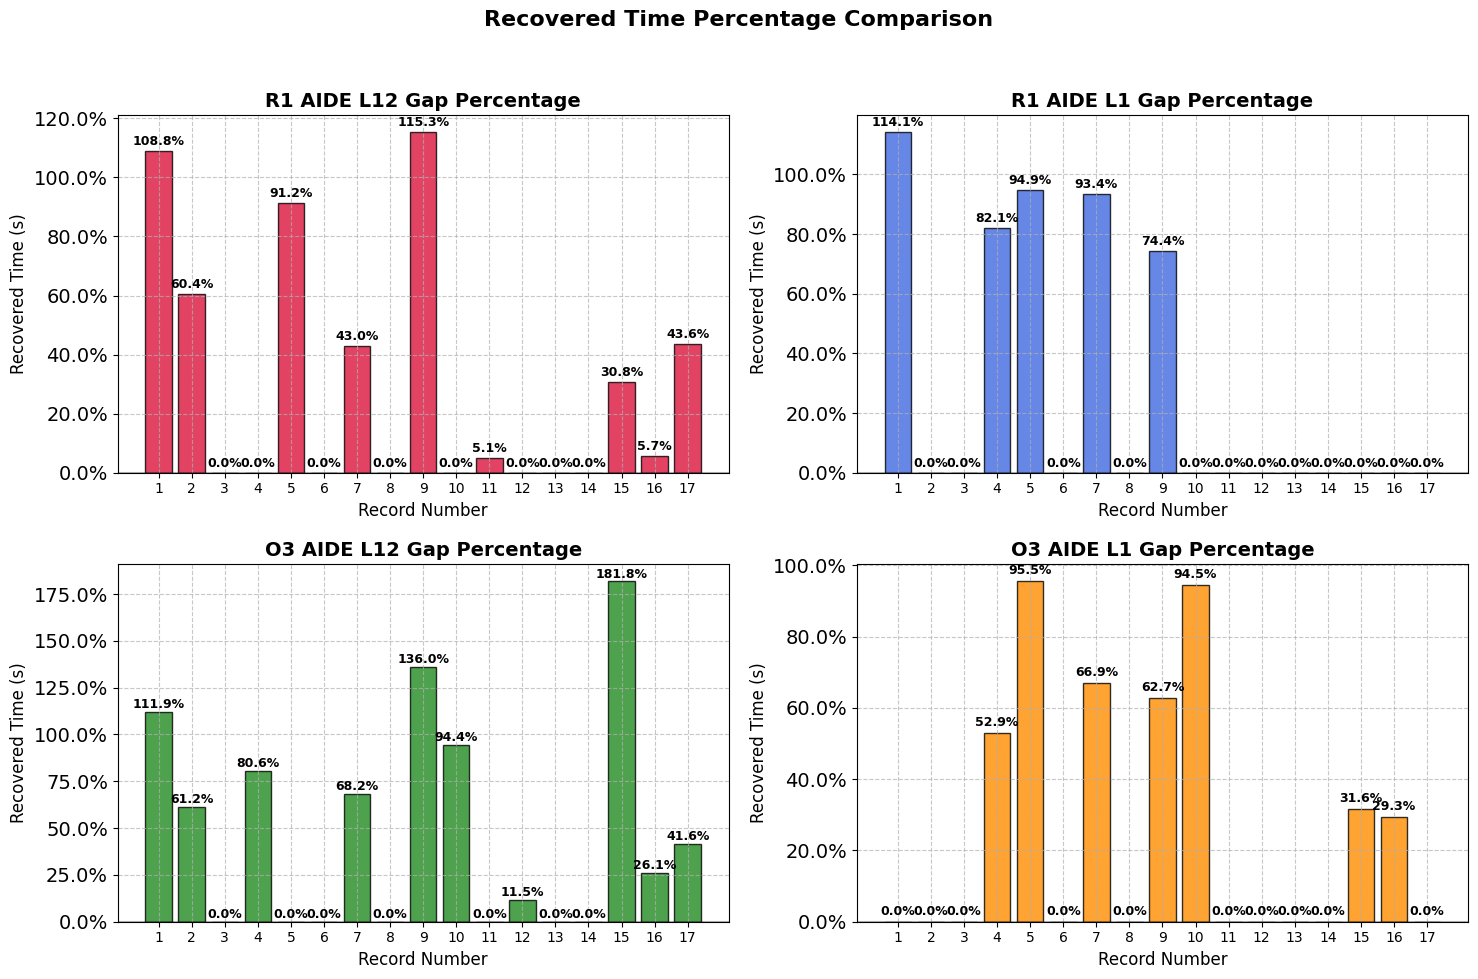

In [19]:
# Create a list of dictionaries and their titles with different colors
data_dicts = [
    (r1_aide_l12_gap_in_percentage, "R1 AIDE L12 Gap Percentage", 'crimson'),
    (r1_aide_gap_in_percentage, "R1 AIDE L1 Gap Percentage", 'royalblue'),
    (o3_aide_l12_gap_in_percentage, "O3 AIDE L12 Gap Percentage", 'forestgreen'),
    (o3_aide_gap_in_percentage, "O3 AIDE L1 Gap Percentage", 'darkorange')
]

# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()  # Flatten the 2x2 array to make indexing easier

# Create a barplot for each dictionary
for i, (data_dict, title, color) in enumerate(data_dicts):
    # Sort the dictionary by keys
    sorted_items = sorted(data_dict.items())
    keys = [item[0] for item in sorted_items]
    values = [item[1] for item in sorted_items]
    
    # Create the barplot with the specified color
    bars = axs[i].bar(keys, values, color=color, edgecolor='black', alpha=0.8)
    
    # Add title and labels
    axs[i].set_title(title, fontsize=14, fontweight='bold')
    axs[i].set_xlabel('Record Number', fontsize=12)
    axs[i].set_ylabel('Recovered Time (s)', fontsize=12)
    
    # Ensure all xticks are shown
    axs[i].set_xticks(keys)
    axs[i].set_xticklabels(keys, fontsize=10)
    
    # Add grid for better readability
    axs[i].grid(True, linestyle='--', alpha=0.7)
    
    # Add a horizontal line at y=0
    axs[i].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Format y-axis as percentage
    axs[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    
    # Annotate the values on top of the bars
    for bar in bars:
        height = bar.get_height()
        if height >= 0:
            y_pos = height + 0.02
        else:
            y_pos = height - 0.05
        axs[i].text(
            bar.get_x() + bar.get_width()/2.,
            y_pos,
            '{:.1%}'.format(height),
            ha='center', 
            fontsize=9,
            fontweight='bold',
            color='black'
        )

# Add a main title for the figure
fig.suptitle('Recovered Time Percentage Comparison', fontsize=16, fontweight='bold', y=0.98)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for the suptitle

# Show the plot
plt.show()